#### remember taker vs maker strat

we need to pick, size of our trades, entry/exit signal, leverage (borrowing money)

In [93]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import polars as pl
import numpy as np
from datetime import datetime, timedelta
import random

import torch
import torch.nn as nn
import torch.optim as optim
import research

import altair as alt

import binance

In [94]:
import models

model = models.LinearModel(2)

model.load_state_dict(torch.load('8h_2lag_model.pth', weights_only=True))
model.eval()

LinearModel(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)

### Model Params

In [95]:
research.print_model_params(model)

linear.weight:
[[-0.04015294  0.02590557]]
linear.bias:
[0.00038383]


### Mean Reversion

In [96]:
series = [-0.014, 0.011399, -0.012212, 0.01997, -0.01442, 0.01227]
mu = np.mean(series)
mean_reversion_df = pl.DataFrame({'log_return': series, 'mean': mu})
mean_reversion_df

log_return,mean
f64,f64
-0.014,0.000501
0.011399,0.000501
-0.012212,0.000501
0.01997,0.000501
-0.01442,0.000501
0.01227,0.000501


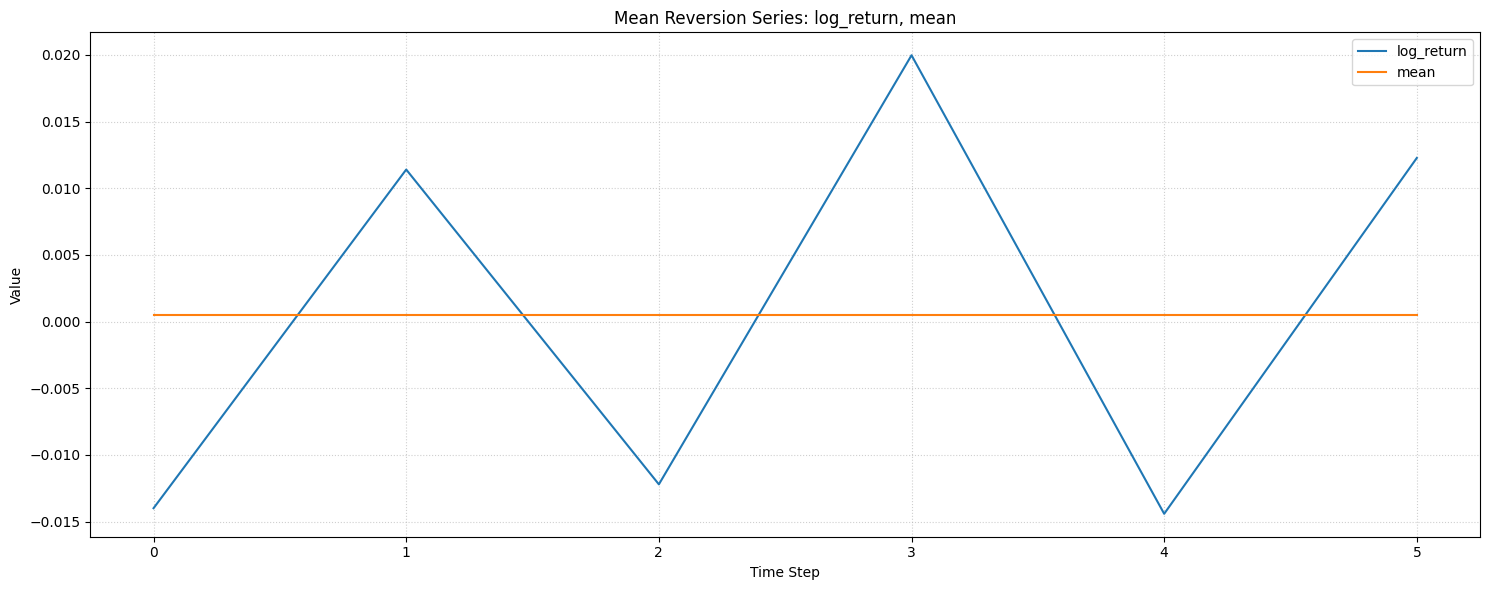

In [97]:
research.plot_multiple_lines(mean_reversion_df, ['log_return', 'mean'], 'Mean Reversion')

## Strategy development

### load time series

In [98]:
sym = 'BTCUSDT'
time_interval='8h'

ts = pl.read_csv(f"../historical_data/{sym}_{time_interval}_ohlc_1yr.csv", try_parse_dates=True).sort('datetime')
ts

datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,94778.5,93445.1,94696.4
2025-05-05 08:00:00,94696.4,94726.8,93559.6,93726.0
2025-05-05 16:00:00,93726.0,95165.1,93705.3,94696.7
2025-05-06 00:00:00,94696.7,94893.3,93961.0,94350.0
2025-05-06 08:00:00,94350.0,94697.2,93327.0,94513.2
…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8


#### add target and features


In [99]:
forecast_horizon = 1
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=3)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,94778.5,93445.1,94696.4,null,null,null,null
2025-05-05 08:00:00,94696.4,94726.8,93559.6,93726.0,-0.0103,null,null,null
2025-05-05 16:00:00,93726.0,95165.1,93705.3,94696.7,0.010304,-0.0103,null,null
2025-05-06 00:00:00,94696.7,94893.3,93961.0,94350.0,-0.003668,0.010304,-0.0103,null
2025-05-06 08:00:00,94350.0,94697.2,93327.0,94513.2,0.001728,-0.003668,0.010304,-0.0103
…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344


In [100]:
test_size = 0.25
_, trades = research.timeseries_split(ts, test_size)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2026-02-03 08:00:00,78750.0,79049.0,77000.5,78094.1,-0.008362,0.000729,-0.001373,0.028159
2026-02-03 16:00:00,78094.2,78101.5,72889.2,75732.4,-0.030708,-0.008362,0.000729,-0.001373
2026-02-04 00:00:00,75732.4,76952.5,75420.0,76478.9,0.009809,-0.030708,-0.008362,0.000729
2026-02-04 08:00:00,76478.9,76568.0,73756.0,74107.0,-0.031505,0.009809,-0.030708,-0.008362
2026-02-04 16:00:00,74107.0,74211.8,71838.0,73137.4,-0.01317,-0.031505,0.009809,-0.030708
…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344


#### strategy decision #1, entry/exit signal

In [101]:
# 1. time based. exit 8 hours later
# 2. predicate based. prediction, but until certain condition is satisfied, make prediction



##### add model predictions

In [102]:
target = 'close_log_return'
features = [f'{target}_lag_2', f'{target}_lag_3']
trades = research.add_model_predictions(trades, model, features)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32
2026-02-03 08:00:00,78750.0,79049.0,77000.5,78094.1,-0.008362,0.000729,-0.001373,0.028159,0.001168
2026-02-03 16:00:00,78094.2,78101.5,72889.2,75732.4,-0.030708,-0.008362,0.000729,-0.001373,0.000319
2026-02-04 00:00:00,75732.4,76952.5,75420.0,76478.9,0.009809,-0.030708,-0.008362,0.000729,0.000738
2026-02-04 08:00:00,76478.9,76568.0,73756.0,74107.0,-0.031505,0.009809,-0.030708,-0.008362,0.0014
2026-02-04 16:00:00,74107.0,74211.8,71838.0,73137.4,-0.01317,-0.031505,0.009809,-0.030708,-0.000806
…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933,0.000535
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224,-0.000224
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344,0.000598


##### add directional signal

In [103]:
trades = trades.with_columns(pl.col('y_hat').sign().alias('dir_signal'))
trades


datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32
2026-02-03 08:00:00,78750.0,79049.0,77000.5,78094.1,-0.008362,0.000729,-0.001373,0.028159,0.001168,1.0
2026-02-03 16:00:00,78094.2,78101.5,72889.2,75732.4,-0.030708,-0.008362,0.000729,-0.001373,0.000319,1.0
2026-02-04 00:00:00,75732.4,76952.5,75420.0,76478.9,0.009809,-0.030708,-0.008362,0.000729,0.000738,1.0
2026-02-04 08:00:00,76478.9,76568.0,73756.0,74107.0,-0.031505,0.009809,-0.030708,-0.008362,0.0014,1.0
2026-02-04 16:00:00,74107.0,74211.8,71838.0,73137.4,-0.01317,-0.031505,0.009809,-0.030708,-0.000806,-1.0
…,…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933,0.000535,1.0
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224,-0.000224,-1.0
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344,0.000598,1.0


#### calc trade log return

In [104]:
trades= trades.with_columns(
    (pl.col('close_log_return') * pl.col('dir_signal')).alias('trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64
2026-02-03 08:00:00,78750.0,79049.0,77000.5,78094.1,-0.008362,0.000729,-0.001373,0.028159,0.001168,1.0,-0.008362
2026-02-03 16:00:00,78094.2,78101.5,72889.2,75732.4,-0.030708,-0.008362,0.000729,-0.001373,0.000319,1.0,-0.030708
2026-02-04 00:00:00,75732.4,76952.5,75420.0,76478.9,0.009809,-0.030708,-0.008362,0.000729,0.000738,1.0,0.009809
2026-02-04 08:00:00,76478.9,76568.0,73756.0,74107.0,-0.031505,0.009809,-0.030708,-0.008362,0.0014,1.0,-0.031505
2026-02-04 16:00:00,74107.0,74211.8,71838.0,73137.4,-0.01317,-0.031505,0.009809,-0.030708,-0.000806,-1.0,0.01317
…,…,…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933,0.000535,1.0,0.003924
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224,-0.000224,-1.0,0.001885
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344,0.000598,1.0,0.012322


#### calc cumulative trade log return

In [105]:
trades = trades.with_columns(
    pl.col('trade_log_return').cum_sum().alias('cum_trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64
2026-02-03 08:00:00,78750.0,79049.0,77000.5,78094.1,-0.008362,0.000729,-0.001373,0.028159,0.001168,1.0,-0.008362,-0.008362
2026-02-03 16:00:00,78094.2,78101.5,72889.2,75732.4,-0.030708,-0.008362,0.000729,-0.001373,0.000319,1.0,-0.030708,-0.039071
2026-02-04 00:00:00,75732.4,76952.5,75420.0,76478.9,0.009809,-0.030708,-0.008362,0.000729,0.000738,1.0,0.009809,-0.029262
2026-02-04 08:00:00,76478.9,76568.0,73756.0,74107.0,-0.031505,0.009809,-0.030708,-0.008362,0.0014,1.0,-0.031505,-0.060767
2026-02-04 16:00:00,74107.0,74211.8,71838.0,73137.4,-0.01317,-0.031505,0.009809,-0.030708,-0.000806,-1.0,0.01317,-0.047597
…,…,…,…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933,0.000535,1.0,0.003924,0.199951
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224,-0.000224,-1.0,0.001885,0.201836
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344,0.000598,1.0,0.012322,0.214158


#### display equity curve (log space)

In [106]:
research.plot_column(trades, 'cum_trade_log_return')

alt.Chart(...)

## Strategy decision #2: Trade sizing

In [107]:
#1. constant trade size
#2. compounding trade size

##### constant sizing

In [108]:
capital = 100
ratio = 1.0
trade_value = ratio * capital

# entry trade value and exit trade value
trades = trades.with_columns(
    pl.lit(trade_value).alias('entry_trade_value'),
    (trade_value * pl.col('trade_log_return').exp()).alias('exit_trade_value'),
    (trade_value / pl.col('open')).alias('trade_qty'),
).with_columns(
    (pl.col('trade_qty') * pl.col('dir_signal')).alias('signed_trade_qty')
)
trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty
datetime[μs],f64,f64,f64,f32,f64,f64,f64
2026-02-03 08:00:00,78750.0,78094.1,-0.008362,0.001168,100.0,99.167237,0.00127
2026-02-03 16:00:00,78094.2,75732.4,-0.030708,0.000319,100.0,96.975828,0.001281
2026-02-04 00:00:00,75732.4,76478.9,0.009809,0.000738,100.0,100.985708,0.00132
2026-02-04 08:00:00,76478.9,74107.0,-0.031505,0.0014,100.0,96.898622,0.001308
2026-02-04 16:00:00,74107.0,73137.4,0.01317,-0.000806,100.0,101.325724,-0.001349
…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,79976.7,0.003924,0.000535,100.0,100.393154,0.001255
2026-05-04 16:00:00,79976.6,79826.1,0.001885,-0.000224,100.0,100.18866,-0.00125
2026-05-05 00:00:00,79826.1,80815.8,0.012322,0.000598,100.0,101.23982,0.001253


#### add trade gross profit and loss

In [109]:
trades = trades.with_columns(
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl')
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64
2026-02-03 08:00:00,78750.0,78094.1,-0.008362,0.001168,100.0,99.167237,0.00127,-0.832763
2026-02-03 16:00:00,78094.2,75732.4,-0.030708,0.000319,100.0,96.975828,0.001281,-3.024172
2026-02-04 00:00:00,75732.4,76478.9,0.009809,0.000738,100.0,100.985708,0.00132,0.985708
2026-02-04 08:00:00,76478.9,74107.0,-0.031505,0.0014,100.0,96.898622,0.001308,-3.101378
2026-02-04 16:00:00,74107.0,73137.4,0.01317,-0.000806,100.0,101.325724,-0.001349,1.325724
…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,79976.7,0.003924,0.000535,100.0,100.393154,0.001255,0.393154
2026-05-04 16:00:00,79976.6,79826.1,0.001885,-0.000224,100.0,100.18866,-0.00125,0.18866
2026-05-05 00:00:00,79826.1,80815.8,0.012322,0.000598,100.0,101.23982,0.001253,1.23982


#### Add transaction fees 

In [110]:
taker_fee = binance.TAKER_FEE
maker_fee = binance.MAKER_FEE

trades = trades.with_columns(
    ((pl.col('entry_trade_value') * taker_fee + pl.col('exit_trade_value') * taker_fee) * pl.col('dir_signal').abs()).alias('taker_fee'),
    ((pl.col('entry_trade_value') * maker_fee + pl.col('exit_trade_value') * maker_fee) * pl.col('dir_signal').abs()).alias('maker_fee')
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl', 'maker_fee', 'taker_fee')


datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,maker_fee,taker_fee
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2026-02-03 08:00:00,78750.0,78094.1,-0.008362,0.001168,100.0,99.167237,0.00127,-0.832763,0.089625,0.089625
2026-02-03 16:00:00,78094.2,75732.4,-0.030708,0.000319,100.0,96.975828,0.001281,-3.024172,0.088639,0.088639
2026-02-04 00:00:00,75732.4,76478.9,0.009809,0.000738,100.0,100.985708,0.00132,0.985708,0.090444,0.090444
2026-02-04 08:00:00,76478.9,74107.0,-0.031505,0.0014,100.0,96.898622,0.001308,-3.101378,0.088604,0.088604
2026-02-04 16:00:00,74107.0,73137.4,0.01317,-0.000806,100.0,101.325724,-0.001349,1.325724,0.090597,0.090597
…,…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,79976.7,0.003924,0.000535,100.0,100.393154,0.001255,0.393154,0.090177,0.090177
2026-05-04 16:00:00,79976.6,79826.1,0.001885,-0.000224,100.0,100.18866,-0.00125,0.18866,0.090085,0.090085
2026-05-05 00:00:00,79826.1,80815.8,0.012322,0.000598,100.0,101.23982,0.001253,1.23982,0.090558,0.090558


##### calc net trade pnl

In [111]:
trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('maker_fee')).alias('trade_net_maker_pnl'),
    (pl.col('trade_gross_pnl') - pl.col('taker_fee')).alias('trade_net_taker_pnl'),
)


trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl', 'trade_net_taker_pnl', 'trade_net_maker_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,trade_net_taker_pnl,trade_net_maker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2026-02-03 08:00:00,78750.0,78094.1,-0.008362,0.001168,100.0,99.167237,0.00127,-0.832763,-0.922388,-0.922388
2026-02-03 16:00:00,78094.2,75732.4,-0.030708,0.000319,100.0,96.975828,0.001281,-3.024172,-3.112811,-3.112811
2026-02-04 00:00:00,75732.4,76478.9,0.009809,0.000738,100.0,100.985708,0.00132,0.985708,0.895264,0.895264
2026-02-04 08:00:00,76478.9,74107.0,-0.031505,0.0014,100.0,96.898622,0.001308,-3.101378,-3.189983,-3.189983
2026-02-04 16:00:00,74107.0,73137.4,0.01317,-0.000806,100.0,101.325724,-0.001349,1.325724,1.235127,1.235127
…,…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,79976.7,0.003924,0.000535,100.0,100.393154,0.001255,0.393154,0.302977,0.302977
2026-05-04 16:00:00,79976.6,79826.1,0.001885,-0.000224,100.0,100.18866,-0.00125,0.18866,0.098575,0.098575
2026-05-05 00:00:00,79826.1,80815.8,0.012322,0.000598,100.0,101.23982,0.001253,1.23982,1.149262,1.149262


#### display equity curves for constant sizing

In [112]:
def equity_curve(capital, col_name, suffix):
    return (capital + (pl.col(col_name).cum_sum())).alias(f'equity_curve_{suffix}')

trades = trades.with_columns(
    equity_curve(capital, 'trade_net_taker_pnl', 'taker'),
    equity_curve(capital, 'trade_net_maker_pnl', 'maker'),
    equity_curve(capital, 'trade_gross_pnl', 'gross'),
)

trades.select('datetime', 'equity_curve_gross', 'equity_curve_taker', 'equity_curve_maker')

datetime,equity_curve_gross,equity_curve_taker,equity_curve_maker
datetime[μs],f64,f64,f64
2026-02-03 08:00:00,99.167237,99.077612,99.077612
2026-02-03 16:00:00,96.143065,95.964801,95.964801
2026-02-04 00:00:00,97.128772,96.860065,96.860065
2026-02-04 08:00:00,94.027394,93.670082,93.670082
2026-02-04 16:00:00,95.353118,94.905209,94.905209
…,…,…,…
2026-05-04 08:00:00,123.134889,98.734479,98.734479
2026-05-04 16:00:00,123.32355,98.833054,98.833054
2026-05-05 00:00:00,124.56337,99.982316,99.982316


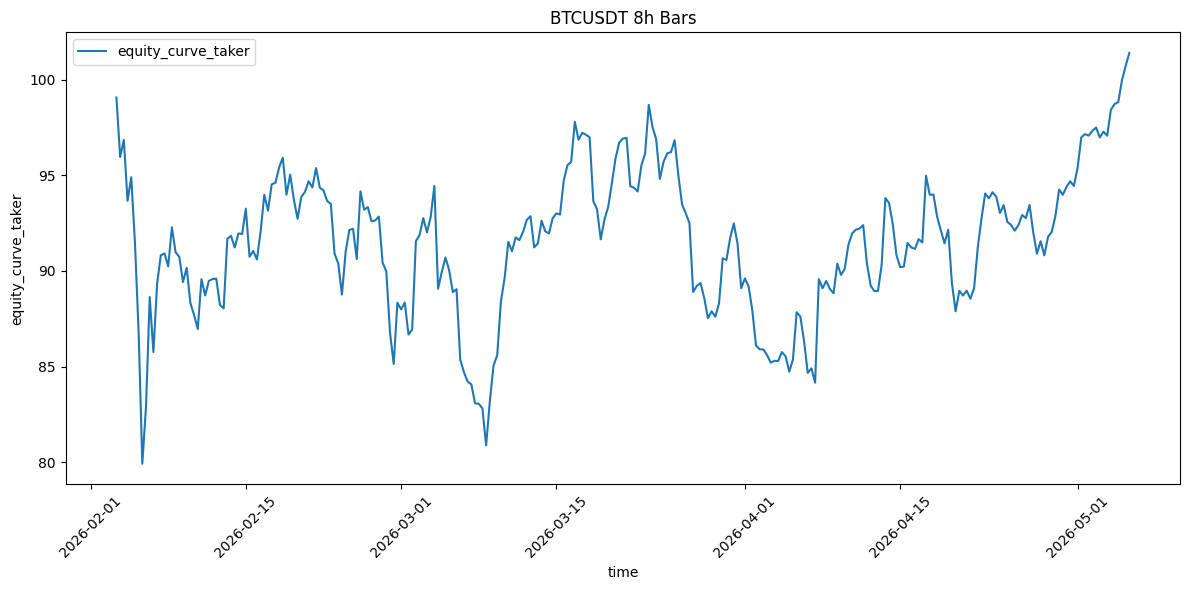

In [113]:
research.plot_static_timeseries(trades, sym, 'equity_curve_taker',time_interval)

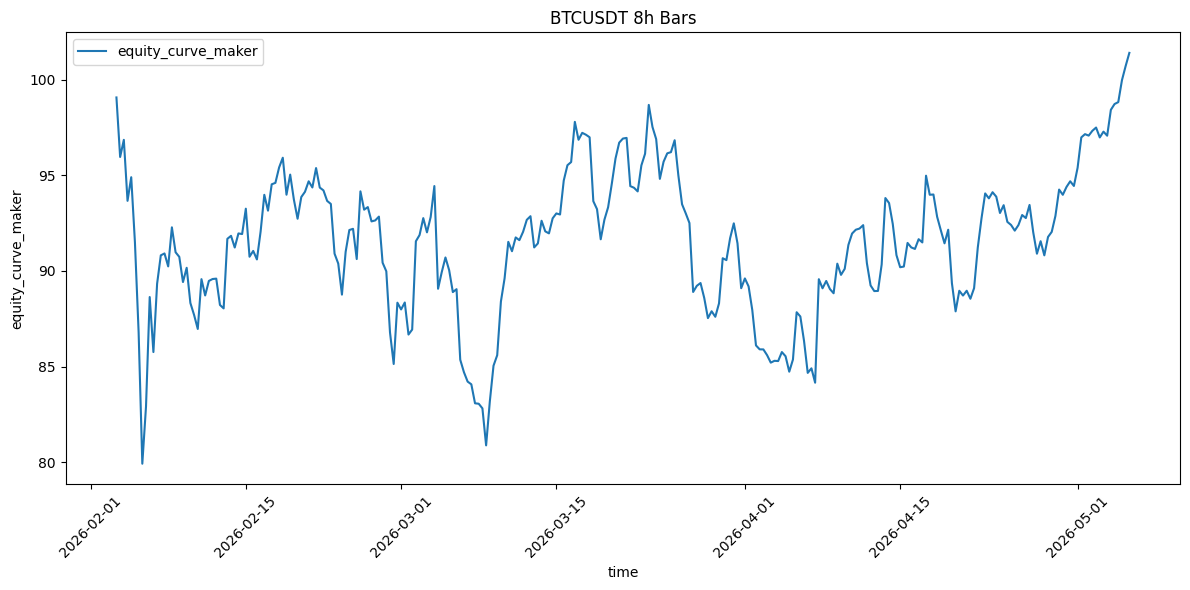

In [114]:
research.plot_static_timeseries(trades, sym, 'equity_curve_maker',time_interval)

### calculate total net return using constant sizing

In [115]:
constant_sizing_net_return = trades['equity_curve_taker'][-1] / capital - 1
constant_sizing_net_return

0.01409375534998114

#### compounding trade sizing

reinvesting earnings basically.

- if you put in 100, and earn two, your next trade you would put in 102
- principle of time additivity

In [116]:
trades = trades.with_columns(
    ((pl.col('cum_trade_log_return').exp()) * capital).shift().fill_null(capital).alias('entry_trade_value'),
    ((pl.col('cum_trade_log_return').exp()) * capital).alias('exit_trade_value')
).with_columns(
    (pl.col('entry_trade_value') / pl.col('open') * pl.col('dir_signal')).alias('signed_trade_qty'),
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl'),
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

datetime,open,close,trade_log_return,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f64,f64,f64,f64
2026-02-03 08:00:00,78750.0,78094.1,-0.008362,100.0,99.167237,0.00127,-0.832763
2026-02-03 16:00:00,78094.2,75732.4,-0.030708,99.167237,96.168249,0.00127,-2.998988
2026-02-04 00:00:00,75732.4,76478.9,0.009809,96.168249,97.116187,0.00127,0.947938
2026-02-04 08:00:00,76478.9,74107.0,-0.031505,97.116187,94.104246,0.00127,-3.01194
2026-02-04 16:00:00,74107.0,73137.4,0.01317,94.104246,95.351809,-0.00127,1.247562
…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,79976.7,0.003924,121.656,122.134295,0.001527,0.478295
2026-05-04 16:00:00,79976.6,79826.1,0.001885,122.134295,122.364714,-0.001527,0.230419
2026-05-05 00:00:00,79826.1,80815.8,0.012322,122.364714,123.881816,0.001533,1.517102


##### add transaction fees

In [117]:
trades = research.add_tx_fees(trades, binance.MAKER_FEE, binance.TAKER_FEE)
trades.select('datetime', 'entry_trade_value', 'exit_trade_value', 'tx_fee_maker', 'tx_fee_taker')

datetime,entry_trade_value,exit_trade_value,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64
2026-02-03 08:00:00,100.0,99.167237,0.089625,0.089625
2026-02-03 16:00:00,99.167237,96.168249,0.087901,0.087901
2026-02-04 00:00:00,96.168249,97.116187,0.086978,0.086978
2026-02-04 08:00:00,97.116187,94.104246,0.086049,0.086049
2026-02-04 16:00:00,94.104246,95.351809,0.085255,0.085255
…,…,…,…,…
2026-05-04 08:00:00,121.656,122.134295,0.109706,0.109706
2026-05-04 16:00:00,122.134295,122.364714,0.110025,0.110025
2026-05-05 00:00:00,122.364714,123.881816,0.110811,0.110811


#### add trade net pnl

In [118]:
trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('tx_fee_taker')).alias('trade_net_taker_pnl')
)

trades.select('datetime', 'open', 'close', 'close_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'trade_gross_pnl', 'trade_net_taker_pnl')

datetime,open,close,close_log_return,y_hat,entry_trade_value,exit_trade_value,trade_gross_pnl,trade_net_taker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64
2026-02-03 08:00:00,78750.0,78094.1,-0.008362,0.001168,100.0,99.167237,-0.832763,-0.922388
2026-02-03 16:00:00,78094.2,75732.4,-0.030708,0.000319,99.167237,96.168249,-2.998988,-3.086889
2026-02-04 00:00:00,75732.4,76478.9,0.009809,0.000738,96.168249,97.116187,0.947938,0.86096
2026-02-04 08:00:00,76478.9,74107.0,-0.031505,0.0014,97.116187,94.104246,-3.01194,-3.09799
2026-02-04 16:00:00,74107.0,73137.4,-0.01317,-0.000806,94.104246,95.351809,1.247562,1.162307
…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,79976.7,0.003924,0.000535,121.656,122.134295,0.478295,0.368589
2026-05-04 16:00:00,79976.6,79826.1,-0.001885,-0.000224,122.134295,122.364714,0.230419,0.120394
2026-05-05 00:00:00,79826.1,80815.8,0.012322,0.000598,122.364714,123.881816,1.517102,1.406291


### Display equity curve (compounding)

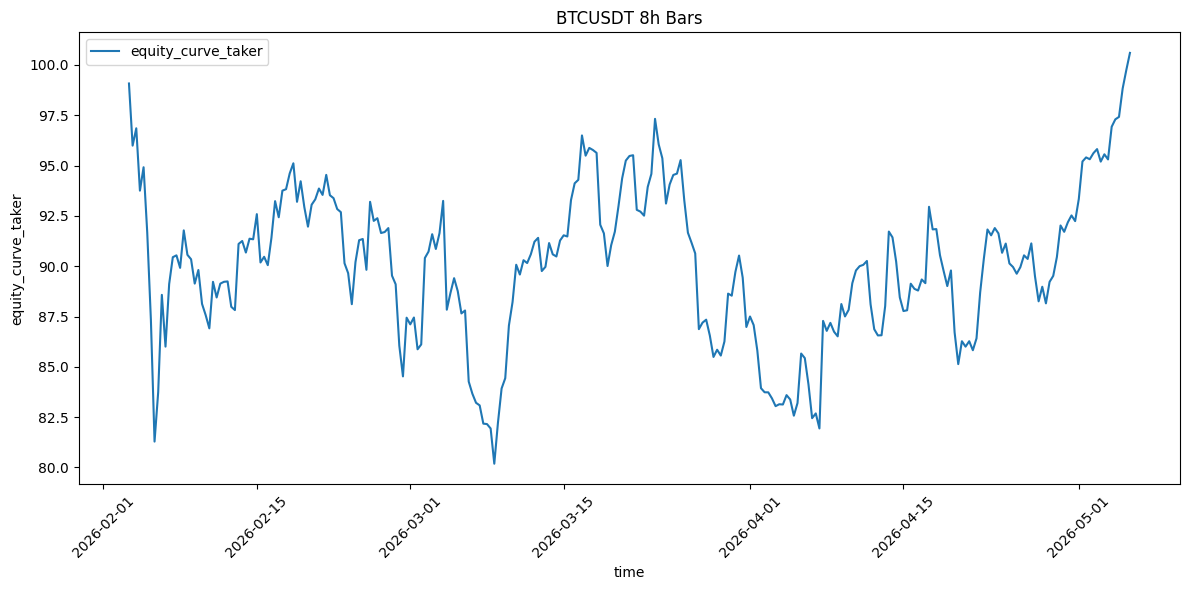

In [119]:
trades = research.add_equity_curve(trades, capital, 'trade_net_taker_pnl', 'taker')
research.plot_static_timeseries(trades, sym, 'equity_curve_taker', time_interval)

### calculate total net return for compounding trade sizing

In [120]:
compound_total_net_return = trades['equity_curve_taker'][-1] / capital - 1
compound_total_net_return

0.0059864651307981465

In [121]:
constant_sizing_net_return

0.01409375534998114

In [122]:
np.round(compound_total_net_return - constant_sizing_net_return, 3)

np.float64(-0.008)

### Strategy decision #3, leverage

borrowing money?


In [123]:
leverage = 4
trades = research.add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-02-03 08:00:00,78750.0,79049.0,77000.5,78094.1,-0.008362,0.000729,-0.001373,0.028159,0.001168,1.0,-0.008362,-0.008362,400.0,396.668948,0.00127,0.005079,-3.331052,0.089625,0.089625,-3.689553,-3.689553,96.310447,96.310447,96.668948,0.358501,0.358501
2026-02-03 16:00:00,78094.2,78101.5,72889.2,75732.4,-0.030708,-0.008362,0.000729,-0.001373,0.000319,1.0,-0.030708,-0.039071,396.668948,384.672996,0.001281,0.005079,-11.995952,0.088639,0.088639,-12.347556,-12.347556,83.962892,83.962892,84.672996,0.351604,0.351604
2026-02-04 00:00:00,75732.4,76952.5,75420.0,76478.9,0.009809,-0.030708,-0.008362,0.000729,0.000738,1.0,0.009809,-0.029262,384.672996,388.464747,0.00132,0.005079,3.791751,0.090444,0.090444,3.443839,3.443839,87.40673,87.40673,88.464747,0.347912,0.347912
2026-02-04 08:00:00,76478.9,76568.0,73756.0,74107.0,-0.031505,0.009809,-0.030708,-0.008362,0.0014,1.0,-0.031505,-0.060767,388.464747,376.416986,0.001308,0.005079,-12.047761,0.088604,0.088604,-12.391958,-12.391958,75.014772,75.014772,76.416986,0.344197,0.344197
2026-02-04 16:00:00,74107.0,74211.8,71838.0,73137.4,-0.01317,-0.031505,0.009809,-0.030708,-0.000806,-1.0,0.01317,-0.047597,376.416986,381.407236,0.001349,-0.005079,4.99025,0.090597,0.090597,4.649229,4.649229,79.664001,79.664001,81.407236,0.341021,0.341021
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933,0.000535,1.0,0.003924,0.199951,486.624001,488.537182,0.001255,0.006109,1.91318,0.090177,0.090177,1.474358,1.474358,89.188121,89.188121,188.537182,0.438823,0.438823
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224,-0.000224,-1.0,0.001885,0.201836,488.537182,489.458856,0.00125,-0.006109,0.921675,0.090085,0.090085,0.481577,0.481577,89.669698,89.669698,189.458856,0.440098,0.440098
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344,0.000598,1.0,0.012322,0.214158,489.458856,495.527266,0.001253,0.006132,6.068409,0.090558,0.090558,5.625165,5.625165,95.294863,95.294863,195.527266,0.443244,0.443244


#### calculate total net return

In [124]:
trades['equity_curve_taker'][-1] / capital -1

0.023945860523192586

#### increase to 8x leverage? (US legal limit)

In [125]:
leverage = 8
trades = research.add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-02-03 08:00:00,78750.0,79049.0,77000.5,78094.1,-0.008362,0.000729,-0.001373,0.028159,0.001168,1.0,-0.008362,-0.008362,800.0,793.337896,0.00127,0.010159,-6.662104,0.089625,0.089625,-7.379106,-7.379106,92.620894,92.620894,93.337896,0.717002,0.717002
2026-02-03 16:00:00,78094.2,78101.5,72889.2,75732.4,-0.030708,-0.008362,0.000729,-0.001373,0.000319,1.0,-0.030708,-0.039071,793.337896,769.345993,0.001281,0.010159,-23.991903,0.088639,0.088639,-24.695111,-24.695111,67.925783,67.925783,69.345993,0.703208,0.703208
2026-02-04 00:00:00,75732.4,76952.5,75420.0,76478.9,0.009809,-0.030708,-0.008362,0.000729,0.000738,1.0,0.009809,-0.029262,769.345993,776.929495,0.00132,0.010159,7.583502,0.090444,0.090444,6.887678,6.887678,74.813461,74.813461,76.929495,0.695824,0.695824
2026-02-04 08:00:00,76478.9,76568.0,73756.0,74107.0,-0.031505,0.009809,-0.030708,-0.008362,0.0014,1.0,-0.031505,-0.060767,776.929495,752.833972,0.001308,0.010159,-24.095523,0.088604,0.088604,-24.783916,-24.783916,50.029545,50.029545,52.833972,0.688394,0.688394
2026-02-04 16:00:00,74107.0,74211.8,71838.0,73137.4,-0.01317,-0.031505,0.009809,-0.030708,-0.000806,-1.0,0.01317,-0.047597,752.833972,762.814472,0.001349,-0.010159,9.9805,0.090597,0.090597,9.298458,9.298458,59.328003,59.328003,62.814472,0.682042,0.682042
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933,0.000535,1.0,0.003924,0.199951,973.248003,977.074363,0.001255,0.012217,3.826361,0.090177,0.090177,2.948715,2.948715,78.376242,78.376242,277.074363,0.877645,0.877645
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224,-0.000224,-1.0,0.001885,0.201836,977.074363,978.917713,0.00125,-0.012217,1.843349,0.090085,0.090085,0.963153,0.963153,79.339395,79.339395,278.917713,0.880196,0.880196
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344,0.000598,1.0,0.012322,0.214158,978.917713,991.054531,0.001253,0.012263,12.136818,0.090558,0.090558,11.250331,11.250331,90.589726,90.589726,291.054531,0.886488,0.886488


In [126]:
trades['equity_curve_taker'][-1] / capital -1

0.047891721046385394

##### wr hasnt changed

In [127]:
trades.select((pl.col('trade_log_return') > 0).mean())

trade_log_return
f64
0.541818


##### basic liquidation model

closing a position

In [128]:
maintenance_margin = 0.005

def long_liquidation_price(p, l, mmr):
    return (p * l) / (l + 1 - mmr * l)

def short_liquidation_price(p, l, mmr):
    return (p * l) / (l - 1 + mmr * 1)

##### show how leverage affects long positions

In [129]:
long_liquidation_price(200, 2, maintenance_margin)

133.7792642140468

In [130]:
long_liquidation_price(200, 4, maintenance_margin)

160.64257028112448

In [131]:
long_liquidation_price(200, 10, maintenance_margin)

182.64840182648402

#### show how leverage affects short positions

In [132]:
short_liquidation_price(200, 2, maintenance_margin)

398.00995024875624

In [133]:
short_liquidation_price(200, 4, maintenance_margin)

266.22296173044924

### add liquidation prices

In [134]:
leverage = 4

In [135]:
trades = trades.with_columns(
    pl.when(pl.col('dir_signal') == 1)
    .then(
        (pl.col('open') * leverage) / (leverage + 1 - maintenance_margin * leverage)
    )
    .when(pl.col('dir_signal') == -1)
    .then(
        (pl.col('open') * leverage) / (leverage - 1 + maintenance_margin * leverage )
    )
    .otherwise(None)
    .alias('liquidation_price')
)

trades.select('datetime', 'open', 'high', 'low', 'close', 'liquidation_price', 'dir_signal')

datetime,open,high,low,close,liquidation_price,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f32
2026-02-03 08:00:00,78750.0,79049.0,77000.5,78094.1,63253.012048,1.0
2026-02-03 16:00:00,78094.2,78101.5,72889.2,75732.4,62726.26506,1.0
2026-02-04 00:00:00,75732.4,76952.5,75420.0,76478.9,60829.236948,1.0
2026-02-04 08:00:00,76478.9,76568.0,73756.0,74107.0,61428.835341,1.0
2026-02-04 16:00:00,74107.0,74211.8,71838.0,73137.4,98154.966887,-1.0
…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,63986.666667,1.0
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,105929.271523,-1.0
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,64117.349398,1.0


### add liquidation flag

In [136]:
trades = trades.with_columns([
    # worst price based on direction
    pl.when(pl.col('dir_signal') == 1)
        .then(pl.col('low'))
        .otherwise(pl.col('high'))
        .alias('worst_price'),
    # liquidation flag
    pl.when(
        (pl.col('dir_signal') == 1) & (pl.col('low') <= pl.col('liquidation_price'))
    )
    .then(True)
    .when(
        (pl.col('dir_signal') == -1) & (pl.col('high') >= pl.col('liquidation_price'))
    )
    .then(True)
    .otherwise(False)
    .alias('liquidated')
])

trades.select('datetime', 'open', 'high', 'low', 'close', 'liquidation_price', 'dir_signal', 'worst_price', 'liquidated')


datetime,open,high,low,close,liquidation_price,dir_signal,worst_price,liquidated
datetime[μs],f64,f64,f64,f64,f64,f32,f64,bool
2026-02-03 08:00:00,78750.0,79049.0,77000.5,78094.1,63253.012048,1.0,77000.5,false
2026-02-03 16:00:00,78094.2,78101.5,72889.2,75732.4,62726.26506,1.0,72889.2,false
2026-02-04 00:00:00,75732.4,76952.5,75420.0,76478.9,60829.236948,1.0,75420.0,false
2026-02-04 08:00:00,76478.9,76568.0,73756.0,74107.0,61428.835341,1.0,73756.0,false
2026-02-04 16:00:00,74107.0,74211.8,71838.0,73137.4,98154.966887,-1.0,74211.8,false
…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,63986.666667,1.0,78128.3,false
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,105929.271523,-1.0,80771.7,false
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,64117.349398,1.0,79761.2,false


### find liquidated trades

In [137]:
trades.filter(pl.col('liquidated') == True)

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker,liquidation_price,worst_price,liquidated
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
